In [2]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from utils import plot_yearly_seasonality, plot_weekly_seasonality, plot_daily_seasonality, check_stationarity, identifying_model_parameters
project_root = Path.cwd().parent  # when notebook runs from eda/
sys.path.insert(0, str(project_root))
from common.loader import load_panel

In [3]:
df = load_panel()

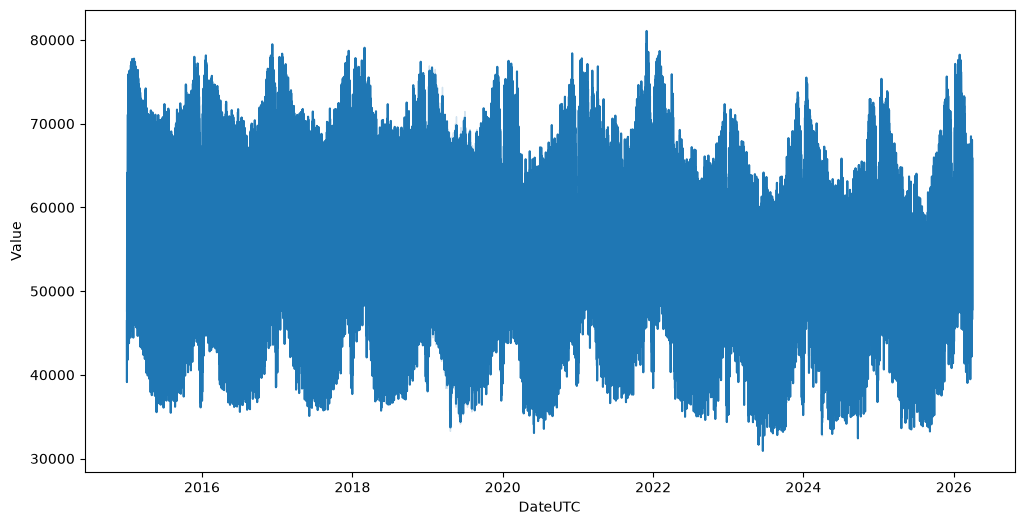

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="Value")
plt.show()

In [8]:
# Defining required fields
df['year'] = [x for x in df.index.year]
df['month'] = [x for x in df.index.month]
df = df.reset_index()
df['week'] = df['DateUTC'].apply(lambda x:x.week)
df = df.set_index('DateUTC')
df['hour'] = [x for x in df.index.hour]
df['day'] = [x for x in df.index.day_of_week]
df['day_str'] = [x.strftime('%a') for x in df.index]
df['year_month'] = [str(x.year) + '_' + str(x.month) for x in df.index]

In [9]:
print(df.groupby("year")["month"].max())

year
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     3
Name: month, dtype: int64


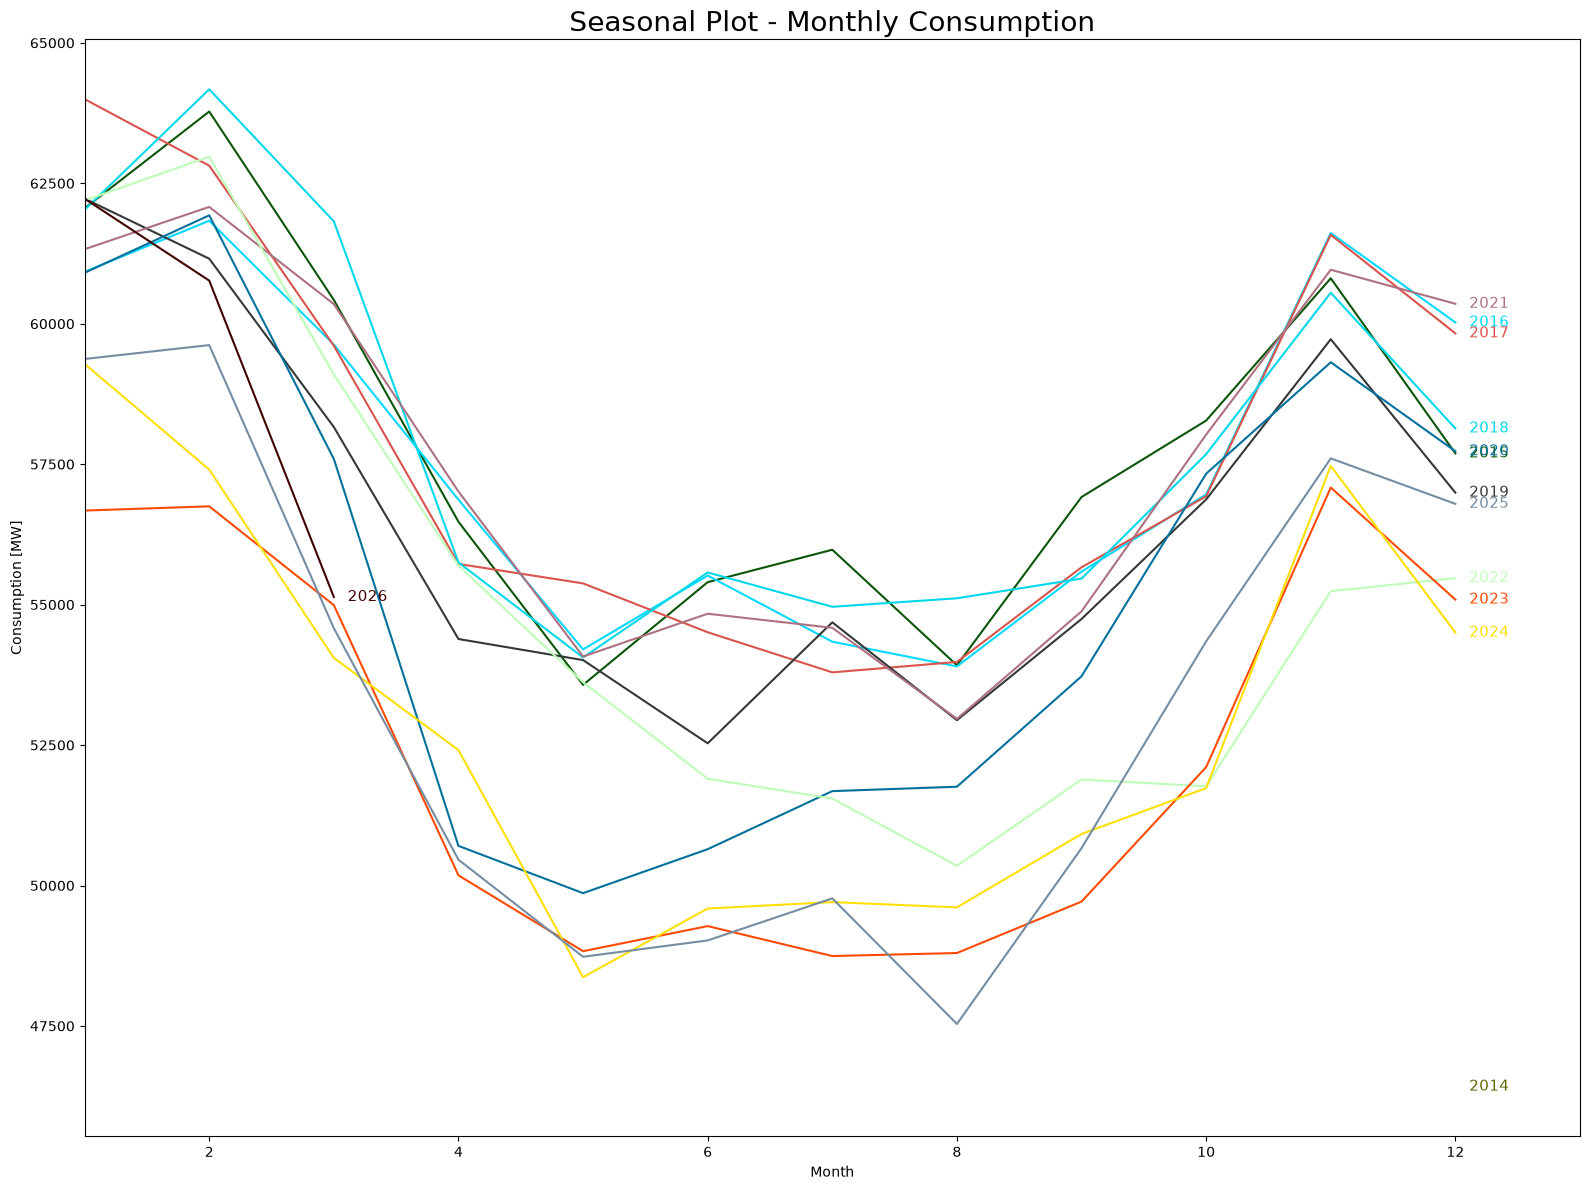

In [10]:
plot_yearly_seasonality(df)

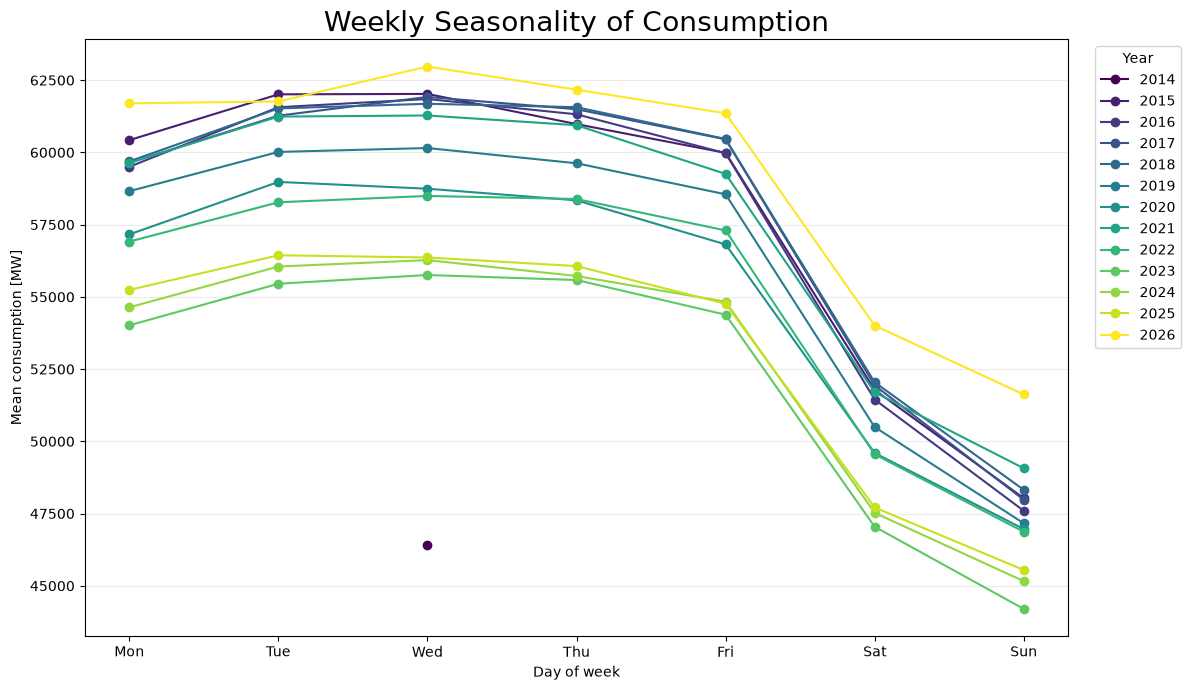

In [11]:
plot_weekly_seasonality(df)

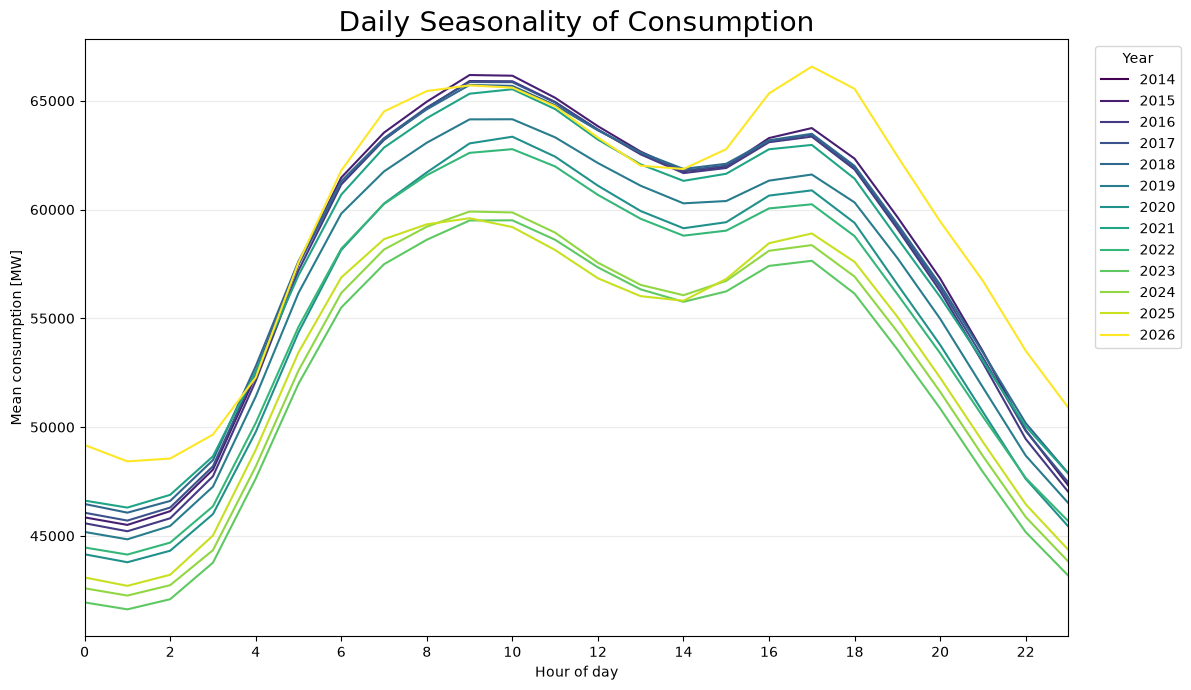

In [12]:
plot_daily_seasonality(df)

In [15]:
check_stationarity(df["Value"])

ADF Statistic: -23.301889136439137
p-value: 0.0
Stationary


/Users/timomeyer/Documents/bachelorarbeit_code/eda/utils.py:152: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(timeseries, autolag="AIC")


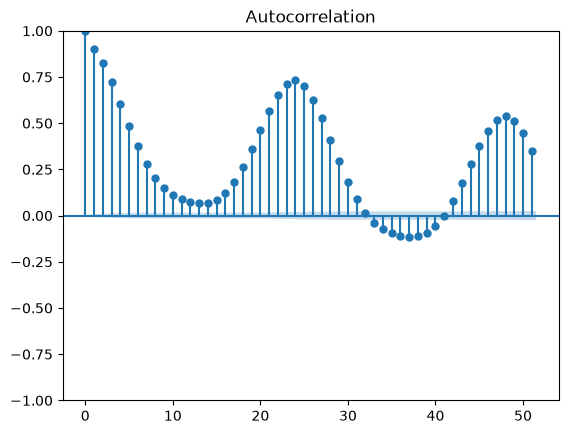

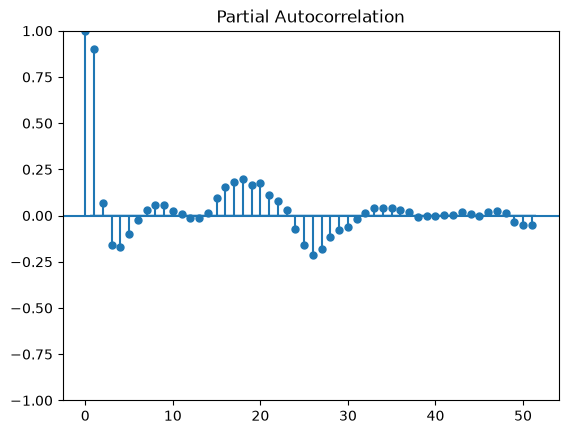

In [16]:
identifying_model_parameters(df["Value"])